In [1]:
import os
wdir=!echo $PWD
os.chdir("/home6/afahad/.ipython/")
from aoespy import *
os.chdir(wdir[0])

/home6/afahad/.ipython/aoespy.py:19: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
import xarray as xr
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

In [3]:
ME506s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-05-05','2005-06-30'))

In [4]:
ME506s2=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4').sel(time=slice('2005-05-05','2005-06-30'))

In [5]:
ME506=xr.concat([ME506s,ME506s2],dim='time')

In [6]:
olr=ME506s.OLR.compute(scheduler='sync')
olr = olr.assign_coords(lon=((olr.lon + 360) % 360)).sortby("lon")

In [7]:
olr

<xarray.DataArray 'OLR' (time: 208, lat: 181, lon: 360)> Size: 54MB
array([[[ 84.478065,  84.478065,  84.478065, ...,  84.478065,
          84.478065,  84.478065],
        [ 84.32746 ,  84.31718 ,  84.3071  , ...,  84.359146,
          84.34849 ,  84.33791 ],
        [ 85.420204,  85.28457 ,  85.14861 , ...,  85.822685,
          85.68951 ,  85.55527 ],
        ...,
        [146.70764 , 146.75906 , 146.80933 , ..., 146.54735 ,
         146.60168 , 146.65515 ],
        [146.52463 , 146.53168 , 146.53865 , ..., 146.5032  ,
         146.51036 , 146.51752 ],
        [146.80228 , 146.80228 , 146.80228 , ..., 146.80228 ,
         146.80228 , 146.80228 ]],

       [[127.686066, 127.686066, 127.686066, ..., 127.686066,
         127.686066, 127.686066],
        [127.981575, 127.945946, 127.91014 , ..., 128.08684 ,
         128.05208 , 128.01698 ],
        [129.97507 , 129.77687 , 129.57872 , ..., 130.56721 ,
         130.3705  , 130.17303 ],
...
        [232.14268 , 232.30902 , 232.47424 , ..., 231.63742 ,
         231.80684 , 231.97527 ],
        [230.4834  , 230.52177 , 230.55933 , ..., 230.36409 ,
         230.40446 , 230.44427 ],
        [230.94473 , 230.94473 , 230.94473 , ..., 230.94473 ,
         230.94473 , 230.94473 ]],

       [[105.49305 , 105.49305 , 105.49305 , ..., 105.49305 ,
         105.49305 , 105.49305 ],
        [106.83986 , 106.81841 , 106.796555, ..., 106.901726,
         106.88151 , 106.86089 ],
        [107.92223 , 107.89336 , 107.86424 , ..., 108.0071  ,
         107.97916 , 107.95086 ],
        ...,
        [231.82443 , 232.00197 , 232.17706 , ..., 231.27852 ,
         231.46259 , 231.64459 ],
        [229.33932 , 229.38792 , 229.43553 , ..., 229.18835 ,
         229.2395  , 229.28986 ],
        [229.10165 , 229.10165 , 229.10165 , ..., 229.10165 ,
         229.10165 , 229.10165 ]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * time     (time) datetime64[ns] 2kB 2005-05-06T01:30:00 ... 2005-05-31T22:...
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    fmissing_value:  1000000000000000.0
    long_name:       upwelling_longwave_flux_at_toa
    regrid_method:   bilinear
    standard_name:   upwelling_longwave_flux_at_toa
    units:           W m-2
    valid_range:     [-1.e+15  1.e+15]
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0

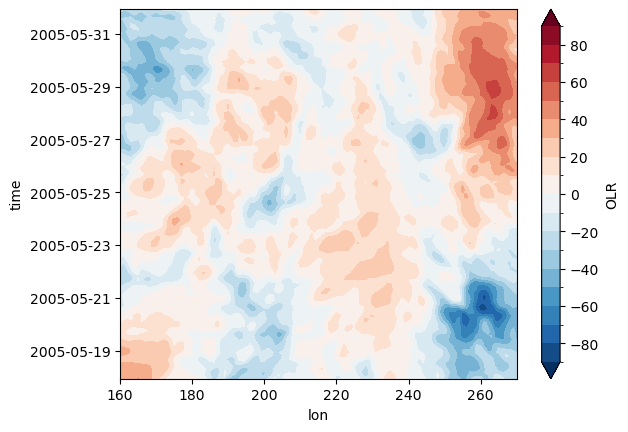

In [17]:
# Number of steps in 14 days for 3-hourly data
window = 12 * 8  # 112 steps

# Compute 14-day running mean (centered)
olr_14day_mean = olr.rolling(time=window, center=False).mean()

#olr=olr-olr.mean(dim='lon')
# Compute anomalies: original - running mean
olr_anom = olr - olr_14day_mean

# Optional: drop NaNs from edges caused by rolling
olr_anom = olr_anom.dropna(dim='time', how='all')

#olr_anom= olr_anom-olr_anom.mean(dim=['lon'])

# Save anomalies if needed
# olr_anom.to_netcdf("olr_14day_anomaly.nc")
#arange(-50,50.1,10)
olranom1=olr_anom.copy()
(olr_anom).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

In [18]:
olr_anom

<xarray.DataArray 'OLR' (time: 113, lat: 181, lon: 360)> Size: 29MB
array([[[  4.501091  ,   4.501091  ,   4.501091  , ...,   4.501091  ,
           4.501091  ,   4.501091  ],
        [ -4.5009384 ,  -4.5966187 ,  -4.691414  , ...,  -4.2078247 ,
          -4.306694  ,  -4.4043884 ],
        [ -8.00206   ,  -7.995743  ,  -7.9895554 , ...,  -8.021973  ,
          -8.015121  ,  -8.008461  ],
        ...,
        [  3.6888275 ,   3.8117676 ,   3.936676  , ...,   3.3322296 ,
           3.449234  ,   3.5681    ],
        [  0.4709015 ,   0.46072388,   0.44831848, ...,   0.48968506,
           0.48532104,   0.47912598],
        [ -0.12548828,  -0.12548828,  -0.12548828, ...,  -0.12548828,
          -0.12548828,  -0.12548828]],

       [[ 11.25473   ,  11.25473   ,  11.25473   , ...,  11.25473   ,
          11.25473   ,  11.25473   ],
        [  0.63842773,   0.5919647 ,   0.54888916, ...,   0.79888916,
           0.7417908 ,   0.6883087 ],
        [ -8.053642  ,  -8.065979  ,  -8.078712  , ...,  -8.018761  ,
          -8.029991  ,  -8.041611  ],
...
        [  6.6836395 ,   6.854492  ,   7.02417   , ...,   6.168091  ,
           6.3406525 ,   6.5128174 ],
        [  5.659607  ,   5.6980133 ,   5.7355347 , ...,   5.541519  ,
           5.581238  ,   5.620819  ],
        [  6.6956177 ,   6.6956177 ,   6.6956177 , ...,   6.6956177 ,
           6.6956177 ,   6.6956177 ]],

       [[-10.913094  , -10.913094  , -10.913094  , ..., -10.913094  ,
         -10.913094  , -10.913094  ],
        [ -9.649399  ,  -9.612152  ,  -9.574905  , ...,  -9.76297   ,
          -9.724922  ,  -9.687111  ],
        [ -9.26429   ,  -9.175179  ,  -9.085945  , ...,  -9.531792  ,
          -9.442764  ,  -9.353516  ],
        ...,
        [  6.2387543 ,   6.418686  ,   6.596161  , ...,   5.6890564 ,
           5.874054  ,   6.0576477 ],
        [  4.40361   ,   4.4514008 ,   4.498123  , ...,   4.2564087 ,
           4.3060455 ,   4.355316  ],
        [  4.743088  ,   4.743088  ,   4.743088  , ...,   4.743088  ,
           4.743088  ,   4.743088  ]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * time     (time) datetime64[ns] 904B 2005-05-17T22:30:00 ... 2005-05-31T22...
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0

In [19]:
ME416s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_surf/200504/*surf*200504*z.nc4')#.sel(time=slice('2005-04-05','2005-06-30'))

In [20]:
ME416s2=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_surf/200505/*surf*200505*z.nc4')#.sel(time=slice('2005-04-05','2005-06-30'))

In [21]:
ME416=xr.concat([ME416s,ME416s2],dim='time')

In [22]:
olr2=ME416.OLR.compute(scheduler='sync')
olr2 = olr2.assign_coords(lon=((olr2.lon + 360) % 360)).sortby("lon")

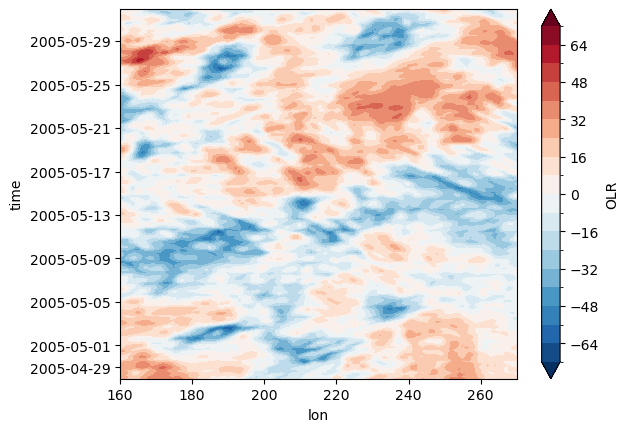

In [23]:
# Number of steps in 14 days for 3-hourly data
window = 12 * 8  # 112 steps

# Compute 14-day running mean (centered)
olr_14day_mean = olr2.rolling(time=window, center=False).mean()

#olr=olr-olr.mean(dim='lon')
# Compute anomalies: original - running mean
olr_anom = olr2 - olr_14day_mean

# Optional: drop NaNs from edges caused by rolling
olr_anom = olr_anom.dropna(dim='time', how='all')

#olr_anom= olr_anom-olr_anom.mean(dim=['lon'])

# Save anomalies if needed
# olr_anom.to_netcdf("olr_14day_anomaly.nc")
#arange(-50,50.1,10)
olranom2=olr_anom.copy()

(olr_anom).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

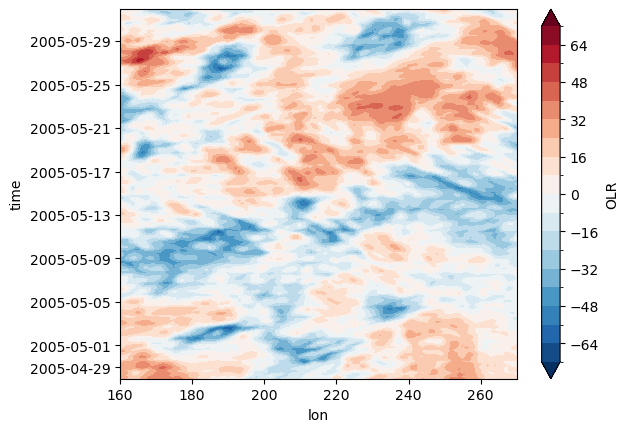

In [24]:
(olranom2).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

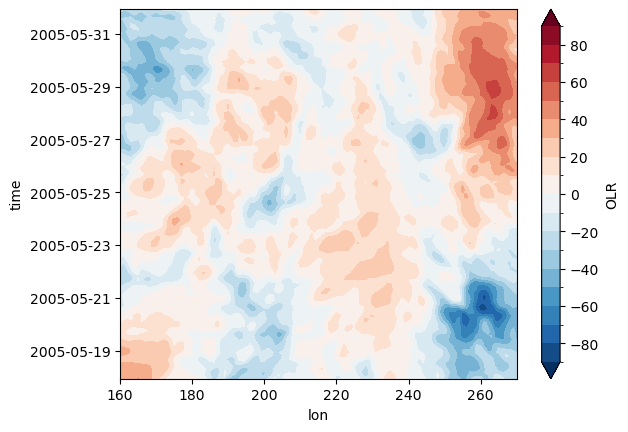

In [25]:
(olranom1).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

In [26]:
#wave=(olranom2.sel(time=slice('2005-05-06','2005-05-26')).data+olranom1.sel(time=slice('2005-06-01','2005-06-21')))/2

In [27]:
wave=(olranom2.sel(time=slice('2005-05-05','2005-05-20')).data+olranom1.sel(time=slice('2005-06-01','2005-06-16')))/2

ValueError: operands could not be broadcast together with shapes (128,181,360) (0,181,360) 

In [28]:
wave=(olranom2.sel(time=slice('2005-05-03','2005-05-28')).data+olranom1.sel(time=slice('2005-05-30','2005-06-24')))/2

ValueError: operands could not be broadcast together with shapes (208,181,360) (16,181,360) 

In [ ]:
wave=wave.resample(time="1D").mean()
wave=wave.assign_coords(time=wave.time - pd.Timedelta(days=25))

In [ ]:
f()
(wave).sel(lat=slice(-15,15),lon=slice(120,290)).mean(dim='lat').plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both')
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-12)
plt.ylabel('Lag/Lead days')

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=13)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom.png',dpi=150)
plt.show()

In [ ]:
f()
(wave).sel(lat=slice(-15,15),lon=slice(120,290)).mean(dim='lat').plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both')
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-12)
plt.ylabel('Lag/Lead days')

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=13)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom.png',dpi=150)
plt.show()

In [ ]:
ME416C=load('omega_spike.npz')['ME416C']
ME506C=load('omega_spike.npz')['ME506C']

lon=load('omega_spike.npz')['lon']
lat=load('omega_spike.npz')['lat']

In [ ]:
time416=pd.date_range('2005-04-16', periods=64*4, freq='6H')
time506=pd.date_range('2005-05-06', periods=64*4, freq='6H')

In [ ]:
ME506 = xr.Dataset(
    {
        "sp": (("lat", "lon", "time"), ME506C)  # data variable
    },
    coords={
        "lon": lon,
        "lat": lat,
        "time": time506,
    }
)

In [ ]:
ME416 = xr.Dataset(
    {
        "sp": (("lat", "lon", "time"), ME416C)  # data variable
    },
    coords={
        "lon": lon,
        "lat": lat,
        "time": time416,
    }
)

In [ ]:
ME416=ME416.assign_coords(lon=((ME416.lon + 360) % 360)).sortby("lon").sel(lat=slice(-15,15),lon=slice(120,290))
ME506=ME506.assign_coords(lon=((ME506.lon + 360) % 360)).sortby("lon").sel(lat=slice(-15,15),lon=slice(120,290))

In [ ]:
ME506=ME506.sel(time=slice('2005-05-30','2005-06-24')).resample(time="1D").mean()
ME416=ME416.sel(time=slice('2005-05-03','2005-05-28')).resample(time="1D").mean()

In [ ]:
ME506=ME506.sum(dim='lat')
ME416=ME416.sum(dim='lat')

In [ ]:
sp=((ME416.sp.data+ME506.sp))

In [ ]:
sp=sp.assign_coords(time=sp.time - pd.Timedelta(days=25))

In [ ]:
wave=(wave).sel(lat=slice(-15,15),lon=slice(120,290)).mean(dim='lat')

In [ ]:
f()
wave.plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both',alpha=.85)
cs=sp.plot.contour(colors='black',levels=array([.25]),alpha=.5)
#plt.clabel(cs, inline=True, fontsize=8, fmt=lambda val: f"{val:.1f}")
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-10,fontsize=12)
plt.ylabel('Lag/Lead days',fontsize=14)

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=11)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom.png',dpi=150)
plt.show()

## 

In [ ]:
f()
(sp).plot.contourf()